<a href="https://colab.research.google.com/github/kowsik005/ml_supervised_project/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Model Evaluation ---
Accuracy: 97.50%

              precision    recall  f1-score   support

     Class 0       1.00      0.96      0.98        26
     Class 1       0.93      1.00      0.97        14

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40

--- Decision Rules ---
|--- Feature_C <= -0.27
|   |--- Feature_B <= 0.98
|   |   |--- Feature_B <= -0.97
|   |   |   |--- class: 0
|   |   |--- Feature_B >  -0.97
|   |   |   |--- class: 0
|   |--- Feature_B >  0.98
|   |   |--- Feature_A <= -0.94
|   |   |   |--- class: 0
|   |   |--- Feature_A >  -0.94
|   |   |   |--- class: 1
|--- Feature_C >  -0.27
|   |--- Feature_B <= -1.20
|   |   |--- Feature_C <= 1.06
|   |   |   |--- class: 0
|   |   |--- Feature_C >  1.06
|   |   |   |--- class: 1
|   |--- Feature_B >  -1.20
|   |   |--- Feature_B <= -0.37
|   |   |   |--- class: 1
|   |   |--- Feature_B >  -0.37
|   |   |   |

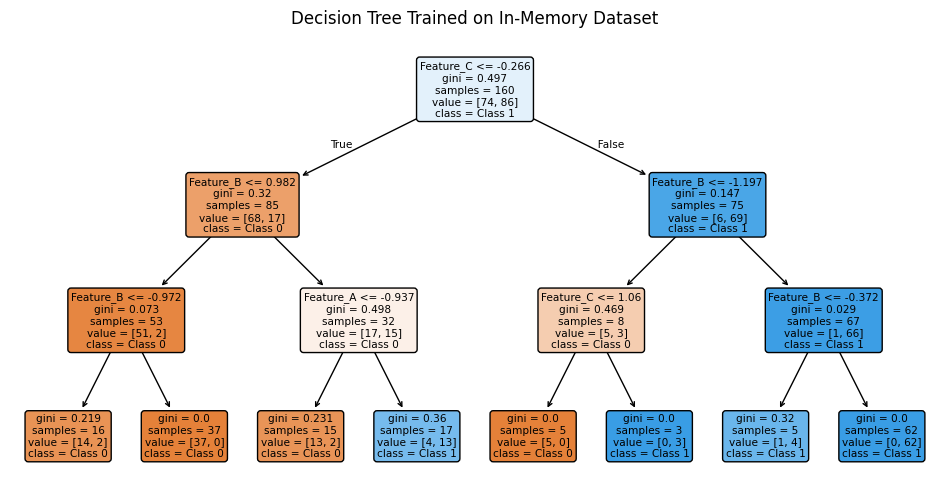

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Generate a synthetic dataset directly in memory (no files needed)
X_raw, y_raw = make_classification(
    n_samples=200,      # Number of samples
    n_features=4,       # Number of features
    n_informative=3,    # Number of useful features
    n_redundant=0,      # No redundant features
    random_state=42
)

# Convert to DataFrame with custom column names
feature_names = ['Feature_A', 'Feature_B', 'Feature_C', 'Feature_D']
X = pd.DataFrame(X_raw, columns=feature_names)
y = pd.Series(y_raw, name='Target')

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Make Predictions & Evaluate
y_pred = clf.predict(X_test)

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 5. Display Text Rules
print("--- Decision Rules ---")
print(export_text(clf, feature_names=feature_names))

# 6. Plot the Decision Tree Visual
plt.figure(figsize=(12, 6))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Trained on In-Memory Dataset")
plt.show()